In [3]:
# Install required packages (run once)
import subprocess, sys
pkgs = ["torch", "torchvision", "timm", "scikit-learn", "openpyxl",
"pandas", "Pillow", "numpy", "tqdm", "matplotlib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

0

In [4]:
import os, csv, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
import timm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
print(f"PyTorch : {torch.__version__}")
print(f"Device : {'GPU – ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


PyTorch : 2.10.0+cpu
Device : CPU


In [5]:
class Config:
    # ── File paths ─────────────────────────────────────────────────────────
    EXCEL_PATH = r"C:\Users\vishn\Downloads\edit\VF_and_clinical_information.xlsx" # <-- adjust if needed
    IMAGE_DIR = r"C:\Users\vishn\Downloads\edit\Annotated images" # <-- folder with fundus images
    CHECKPOINT_DIR = "checkpoints"
    RESULTS_DIR = "test_results"
    SHEET_NAME = "Baseline"

    # ── Excel column indices (0-based, after pandas reads header row 1) ────
    # Excel cols: C=2, D=3, E=4, F=5, Q=16, T=19 … CB=79
    COL_AGE = 3 # C – Age
    COL_GENDER = 4 # D – Gender
    COL_IOP = 5# E – IOP
    COL_CCT = 6 # F – CCT
    COL_CFP = 17 # Q – Fundus image filename

    # Cols G–K (6–10) and R–S (17–18) are intentionally ignored
    COL_VF_START = 20 # T – first VF point
    COL_VF_END = 81 # CB – last VF point → 61 values

    # ── Model dimensions ────────────────────────────────────────────────────
    VIT_MODEL = "vit_base_patch16_224"
    VIT_EMBED_DIM = 768
    CLINICAL_DIM = 4 # age, gender, IOP, CCT
    MLP_HIDDEN = 128
    MLP_EMBED_DIM = 128
    COND_DIM = VIT_EMBED_DIM + MLP_EMBED_DIM # 896
    VF_DIM = 61

    # ── Diffusion schedule ──────────────────────────────────────────────────
    T_STEPS = 1000
    BETA_START = 5e-5
    BETA_END = 0.01

    # ── Training ────────────────────────────────────────────────────────────
    BATCH_SIZE = 8
    EPOCHS =70
    LR = 1e-4
    TRAIN_RATIO = 0.70 # 70 % train │ 30 % test
    RANDOM_SEED = 42
    IMAGE_SIZE = 224
    NUM_WORKERS = 0
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
print("Config ready. Device:", cfg.DEVICE)

Config ready. Device: cpu


In [6]:
class GRAPEDataset(Dataset):
    """
    Parses the GRAPE Baseline sheet.

    Each __getitem__ returns:
    img  : FloatTensor (3, IMAGE_SIZE, IMAGE_SIZE)
    clin : FloatTensor (4,) – z-scored [Age, Gender, IOP, CCT]
    vf   : FloatTensor (61,) – z-scored VF values (target)
    meta : dict {excel_row, cfp_name, raw_clinical, raw_vf}
    """

    GENDER_MAP = {
        "M": 0.0, "Male": 0.0, "male": 0.0, "m": 0.0,
        "F": 1.0, "Female": 1.0, "female": 1.0, "f": 1.0,
    }

    def __init__(self, excel_path: str, image_dir: str):

        self.image_dir = Path(image_dir)

        # Image transform
        self.img_transform = self._build_transform()

        # Parse Excel
        self.records = self._parse_excel(excel_path)

        print(f"[INPUT READING] {len(self.records)} valid samples from '{excel_path}'")

        # Normalisation stats (injected later)
        self.clin_mean = None
        self.clin_std = None
        self.vf_mean = None
        self.vf_std = None

    @staticmethod
    def _build_transform():
        return transforms.Compose([
            transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def _parse_excel(self, excel_path: str):

        df = pd.read_excel(excel_path, sheet_name=cfg.SHEET_NAME, header=0)

        records = []

        for row_idx, row in df.iterrows():

            vals = row.tolist()

            # Image filename
            cfp = vals[cfg.COL_CFP - 1]

            if pd.isna(cfp) or str(cfp).strip() == "":
                continue

            img_path = self.image_dir / str(cfp).strip()

            if not img_path.exists():
                continue

            # Extract VF values
            vf_raw = vals[cfg.COL_VF_START - 1: cfg.COL_VF_END - 1]

            if len(vf_raw) < cfg.VF_DIM:
                continue

            vf = []

            for v in vf_raw[:cfg.VF_DIM]:
                try:
                    fv = float(v)
                    vf.append(0.0 if np.isnan(fv) else fv)
                except (TypeError, ValueError):
                    vf.append(0.0)

            # Clinical features
            try:

                age = float(vals[cfg.COL_AGE - 1])

                gender = float(
                    self.GENDER_MAP.get(
                        str(vals[cfg.COL_GENDER - 1]).strip(),
                        0.0
                    )
                )

                iop = float(vals[cfg.COL_IOP - 1])
                cct = float(vals[cfg.COL_CCT - 1])

            except (TypeError, ValueError):
                continue

            records.append({
                "img_path": img_path,
                "cfp_name": str(cfp).strip(),
                "excel_row": row_idx + 2,
                "raw_clinical": np.array([age, gender, iop, cct], dtype=np.float32),
                "raw_vf": np.array(vf, dtype=np.float32),
            })

        return records

    def set_normalisation_stats(self, clin_mean, clin_std, vf_mean, vf_std):

        self.clin_mean = clin_mean.astype(np.float32)
        self.clin_std = clin_std.astype(np.float32)

        self.vf_mean = vf_mean.astype(np.float32)
        self.vf_std = vf_std.astype(np.float32)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        rec = self.records[idx]

        # Load image
        img = Image.open(rec["img_path"]).convert("RGB")
        img = self.img_transform(img)

        # Clinical features
        clin = torch.tensor(
            (rec["raw_clinical"] - self.clin_mean) / self.clin_std,
            dtype=torch.float32
        )

        # VF target
        vf = torch.tensor(
            (rec["raw_vf"] - self.vf_mean) / self.vf_std,
            dtype=torch.float32
        )

        return img, clin, vf, rec

In [7]:
def build_splits(dataset: GRAPEDataset):
    """
    70 / 30 split with fixed seed.
    Normalisation stats computed from TRAINING indices only – no leakage.
    """

    all_idx = list(range(len(dataset)))

    train_idx, test_idx = train_test_split(
        all_idx,
        train_size=cfg.TRAIN_RATIO,
        random_state=cfg.RANDOM_SEED,
        shuffle=True,
    )

    print(
        f"[SPLIT] Total={len(dataset)} | "
        f"Train={len(train_idx)} (70%) | Test={len(test_idx)} (30%)"
    )

    # Stats from training only
    tr_clin = np.array([dataset.records[i]["raw_clinical"] for i in train_idx])
    tr_vf = np.array([dataset.records[i]["raw_vf"] for i in train_idx])

    clin_mean, clin_std = tr_clin.mean(0), tr_clin.std(0) + 1e-8
    vf_mean, vf_std = tr_vf.mean(0), tr_vf.std(0) + 1e-8

    dataset.set_normalisation_stats(clin_mean, clin_std, vf_mean, vf_std)

    return (
        Subset(dataset, train_idx),
        Subset(dataset, test_idx),
        train_idx,
        test_idx,
    )


def _collate(batch):
    return (
        torch.stack([b[0] for b in batch]),
        torch.stack([b[1] for b in batch]),
        torch.stack([b[2] for b in batch]),
        [b[3] for b in batch],
    )

In [8]:
# Load dataset and print summary statistics
dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)
train_subset, test_subset, train_idx, test_idx = build_splits(dataset)

# Preview a few records
df_preview = pd.DataFrame([
    {
        "excel_row": r["excel_row"],
        "image": r["cfp_name"],
        "age": r["raw_clinical"][0],
        "gender": "F" if r["raw_clinical"][1] == 1.0 else "M",
        "IOP": r["raw_clinical"][2],
        "CCT": r["raw_clinical"][3],
        "VF_mean": round(float(r["raw_vf"].mean()), 2),
        "VF_std": round(float(r["raw_vf"].std()), 2),
    }
    for r in dataset.records[:6]
])

display(df_preview)

[INPUT READING] 263 valid samples from 'C:\Users\vishn\Downloads\edit\VF_and_clinical_information.xlsx'
[SPLIT] Total=263 | Train=184 (70%) | Test=79 (30%)


,excel_row,image,age,gender,IOP,CCT,VF_mean,VF_std
0,3,1_OD_1.jpg,46.0,F,14.7,535.0,19.16,5.08
1,4,1_OS_1.jpg,46.0,F,15.3,525.0,22.85,4.99
2,5,2_OS_1.jpg,57.0,M,15.5,545.0,8.15,9.93
3,6,3_OD_1.jpg,41.0,M,17.0,557.0,23.10,5.46
4,7,4_OS_1.jpg,58.0,M,14.7,487.0,21.59,5.92
5,8,5_OS_1.jpg,59.0,F,19.0,547.0,21.77,6.76


In [ ]:
class FundusViTEncoder(nn.Module):


    def __init__(self, model_name=cfg.VIT_MODEL, pretrained=True, fundus_ckpt=None):
        super().__init__()

        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        if fundus_ckpt and os.path.exists(fundus_ckpt):
            state = torch.load(fundus_ckpt, map_location="cpu")
            key = "model" if "model" in state else "state_dict"
            self.vit.load_state_dict(state.get(key, state), strict=False)

            print(f"[ViT] Loaded fundus checkpoint: {fundus_ckpt}")

    def forward(self, x):
        return self.vit(x)  # (B, 768)

In [9]:
class ClinicalMLP(nn.Module):
    def __init__(self, in_dim=cfg.CLINICAL_DIM, hidden=cfg.MLP_HIDDEN,
                 out_dim=cfg.MLP_EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)  # (B, 128)

In [10]:
class ConditioningFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(cfg.VIT_EMBED_DIM + cfg.MLP_EMBED_DIM, cfg.COND_DIM),
            nn.LayerNorm(cfg.COND_DIM),
            nn.GELU(),
        )

    def forward(self, vit_emb, mlp_emb):
        return self.proj(torch.cat([vit_emb, mlp_emb], dim=-1))  # (B, 896)

In [28]:
class DiffusionSchedule:

    def __init__(self,
                 T=cfg.T_STEPS,
                 beta_start=cfg.BETA_START,
                 beta_end=cfg.BETA_END):

        self.T = T

        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)

        self.betas = betas
        self.alphas = alphas
        self.alpha_bar = alpha_bar

        # Precomputed terms
        self.sqrt_ab = torch.sqrt(alpha_bar)
        self.sqrt_1mab = torch.sqrt(1.0 - alpha_bar)

    def to(self, device):

        for attr in ("betas", "alphas", "alpha_bar", "sqrt_ab", "sqrt_1mab"):
            tensor = getattr(self, attr)
            setattr(self, attr, tensor.to(device))

        return self

    def q_sample(self, x0, t, noise=None):
        """
        Forward diffusion q(x_t | x_0)

        x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise
        """

        if noise is None:
            noise = torch.randn_like(x0)

        # gather values for batch timesteps
        s = self.sqrt_ab[t].view(-1, 1)
        sm = self.sqrt_1mab[t].view(-1, 1)

        xt = s * x0 + sm * noise

        return xt, noise

In [12]:
class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(
            -np.log(10000) *
            torch.arange(half, device=t.device) / (half - 1)
        )
        args = t.float().unsqueeze(-1) * freq.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock1D(nn.Module):
    """Residual block conditioned on time + conditioning vector."""
    def __init__(self, channels, time_dim, cond_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(channels)
        self.fc1 = nn.Linear(channels, channels)
        self.norm2 = nn.LayerNorm(channels)
        self.fc2 = nn.Linear(channels, channels)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, channels)
        )

        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, channels)
        )

    def forward(self, x, t_emb, cond):
        h = self.fc1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb) + self.cond_proj(cond)
        h = self.fc2(F.silu(self.norm2(h)))
        return x + h


class VFDenoiser(nn.Module):
    """
    Predicts noise ε at step t.
    Input : (B,61) x_t + (B,) t + (B,896) cond
    Output : (B,61) predicted noise
    """
    def __init__(self, vf_dim=cfg.VF_DIM, cond_dim=cfg.COND_DIM,
                 hidden=256, depth=6, time_dim=128):
        super().__init__()

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(time_dim),
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )

        self.input_proj = nn.Linear(vf_dim, hidden)

        self.blocks = nn.ModuleList(
            [ResBlock1D(hidden, time_dim, cond_dim) for _ in range(depth)]
        )

        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, vf_dim)
        )

    def forward(self, x_t, t, cond):
        t_emb = self.time_embed(t)
        h = self.input_proj(x_t)

        for block in self.blocks:
            h = block(h, t_emb, cond)

        return self.output_proj(h)

In [13]:
class CDPMVFSynthesizer(nn.Module):
    def __init__(self, fundus_ckpt=None):
        super().__init__()
        self.vit = FundusViTEncoder(fundus_ckpt=fundus_ckpt)
        self.mlp = ClinicalMLP()
        self.fusion = ConditioningFusion()
        self.denoiser = VFDenoiser()

    def encode(self, images, clinical):
        """Fuse fundus image + clinical embeddings → conditioning vector (B,896)."""
        return self.fusion(self.vit(images), self.mlp(clinical))

    def forward(self, images, clinical, x_t, t):
        """Predict noise ε added at diffusion step t."""
        return self.denoiser(x_t, t, self.encode(images, clinical))


# Quick parameter count
_m = CDPMVFSynthesizer()
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del _m

Trainable parameters: 89,173,693


In [14]:
import torch

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example: SD values for 61 VF locations
healthy_sd = torch.tensor([
2.1,2.3,2.5,2.2,2.4,2.6,2.7,2.8,
2.1,2.4,2.3,2.5,2.6,2.2,2.4,2.7,
2.8,2.3,2.1,2.6,2.4,2.5,2.2,2.3,
2.4,2.6,2.7,2.1,2.3,2.5,2.2,2.4,
2.6,2.7,2.8,2.3,2.4,2.1,2.2,2.5,
2.6,2.7,2.4,2.3,2.1,2.5,2.6,2.7,
2.8,2.2,2.3,2.4,2.6,2.1,2.5,2.7,
2.8,2.3,2.4
], dtype=torch.float32)

# Reliability weights
reliability_weights = 1.0 / healthy_sd
reliability_weights = reliability_weights / reliability_weights.max()

# Move to device
reliability_weights = reliability_weights.to(device)

# Check shape
print("Reliability weight shape:", reliability_weights.shape)

Reliability weight shape: torch.Size([59])


In [15]:
vf_all = np.stack([r["raw_vf"] for r in dataset.records])

healthy_sd = torch.tensor(vf_all.std(axis=0), dtype=torch.float32)
epsilon = 1e-6

reliability_weights = 1.0 / (healthy_sd + epsilon)
reliability_weights = reliability_weights / reliability_weights.max()
reliability_weights = reliability_weights.to(device)

print(reliability_weights.shape)

torch.Size([61])


In [16]:
def run_training():

    device = torch.device(cfg.DEVICE)
    print(f"Device: {device}")

    # 4.1 – Load data and create 70/30 split
    dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)
    train_subset, _, train_idx, test_idx = build_splits(dataset)

    # Save split indices so the test cell uses the same 30 %
    np.save(Path(cfg.CHECKPOINT_DIR) / "train_indices.npy", np.array(train_idx))
    np.save(Path(cfg.CHECKPOINT_DIR) / "test_indices.npy", np.array(test_idx))

    print(f"Split indices saved to '{cfg.CHECKPOINT_DIR}/'")

    train_dl = DataLoader(
        train_subset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        collate_fn=_collate
    )

    # 4.2 – Initialise model, schedule, optimiser
    model = CDPMVFSynthesizer().to(device)
    schedule = DiffusionSchedule().to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR)

    lr_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.EPOCHS
    )

    best_loss = float("inf")
    loss_curve = []

    # 4.3 – Epoch loop
    for epoch in range(1, cfg.EPOCHS + 1):

        model.train()
        epoch_loss = 0.0

        for imgs, clin, vf, _ in tqdm(
            train_dl,
            desc=f"Epoch {epoch}/{cfg.EPOCHS}",
            leave=False
        ):

            imgs = imgs.to(device)
            clin = clin.to(device)
            vf = vf.to(device)

            # Sample random diffusion steps
            t = torch.randint(0, cfg.T_STEPS, (imgs.size(0),), device=device)

           # Forward diffusion
            x_t, noise = schedule.q_sample(vf, t)

# Predict noise
            pred_noise = model(imgs, clin, x_t, t)

# Reliability weights
            weights = reliability_weights.unsqueeze(0).expand_as(noise)

# Central VF weighting
            central_weights = torch.ones_like(noise)
            central_weights[:, 20:40] *= 2.5

# Combine both
            final_weights = weights * central_weights

# Weighted loss
            loss = ((pred_noise - noise) ** 2 * final_weights).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        lr_sched.step()

        epoch_loss /= len(train_dl)
        loss_curve.append(epoch_loss)

        print(f"Epoch {epoch:4d} | train_loss = {epoch_loss:.5f}")

        # Save best checkpoint
        if epoch_loss < best_loss:

            best_loss = epoch_loss

            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "train_loss": best_loss,
                "vf_mean": dataset.vf_mean,
                "vf_std": dataset.vf_std,
                "clin_mean": dataset.clin_mean,
                "clin_std": dataset.clin_std,
            }, Path(cfg.CHECKPOINT_DIR) / "best_model.pt")

            print(f"✓ Checkpoint saved (loss={best_loss:.5f})")

    print(f"\nTraining complete. Best loss = {best_loss:.5f}")

    return loss_curve

In [17]:
loss_history = run_training()

Device: cpu
[INPUT READING] 263 valid samples from 'C:\Users\vishn\Downloads\edit\VF_and_clinical_information.xlsx'
[SPLIT] Total=263 | Train=184 (70%) | Test=79 (30%)
Split indices saved to 'checkpoints/'


Epoch 1/70:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch    1 | train_loss = 0.10201
✓ Checkpoint saved (loss=0.10201)


Epoch 2/70:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch    2 | train_loss = 0.07335
✓ Checkpoint saved (loss=0.07335)


...

Epoch   68 | train_loss = 0.00689


Epoch 69/70:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch   69 | train_loss = 0.00956


Epoch 70/70:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch   70 | train_loss = 0.00824

Training complete. Best loss = 0.00583


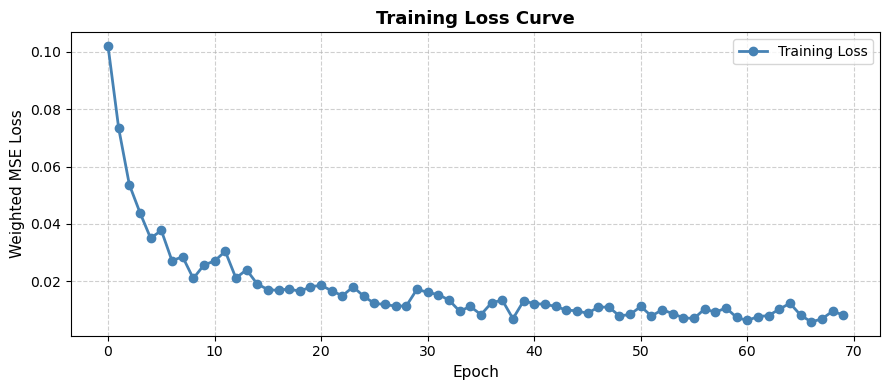

In [18]:
plt.figure(figsize=(9,4))

plt.plot(
    loss_history,
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Training Loss"
)

plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Weighted MSE Loss", fontsize=11)
plt.title("Training Loss Curve", fontsize=13, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()

plt.savefig(Path(cfg.RESULTS_DIR) / "training_loss_curve.png", dpi=150)

plt.show()

In [45]:
@torch.no_grad()
@torch.no_grad()
def ddpm_reverse_sample(model, schedule, cond, device, n_steps=200):
    """
    DDPM reverse diffusion sampling

    x_T ~ N(0, I) → x_0 (synthesised VF in z-score space)

    Parameters
    ----------
    cond : (B, COND_DIM) conditioning vector

    Returns
    -------
    (B, VF_DIM) synthesized VF (z-scored)
    """

    B = cond.size(0)

    # Start from Gaussian noise
    x = torch.randn(B, cfg.VF_DIM) * 0.5 

    for t_idx in tqdm(
        reversed(range(n_steps)),
        desc="DDPM reverse sampling",
        total=n_steps,
        leave=False
    ):

        t = torch.full((B,), t_idx, device=device, dtype=torch.long)
        pred_eps = model.denoiser(x, t, cond)

        # Predict noise
        beta_t = schedule.betas[t_idx].to(device)
        alpha_t = schedule.alphas[t_idx].to(device)
        alpha_bar_t = schedule.alpha_bar[t_idx].to(device)

        if t_idx > 0:
            alpha_bar_prev = schedule.alpha_bar[t_idx - 1].to(device)
        else:
            alpha_bar_prev = torch.tensor(1.0, device=device)

        # Estimate clean sample
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * pred_eps) / torch.sqrt(alpha_bar_t)

        # Clip for stability
        x0_pred = x0_pred.clamp(-3.0, 3.0)

        # Posterior mean
        coef1 = torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)
        coef2 = torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)

        mean = coef1 * x0_pred + coef2 * x

        if t_idx > 0:
            var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            var = torch.clamp(var, min=1e-20)

            noise = torch.randn_like(x)
            x = mean + torch.sqrt(var) * noise
        else:
            x = mean

    return x

In [46]:
def run_test():

    device = torch.device(cfg.DEVICE)

    ckpt_path = Path(cfg.CHECKPOINT_DIR) / "best_model.pt"
    assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}. Run training first."

    print("Loading checkpoint:", ckpt_path)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    # Load model
    model = CDPMVFSynthesizer().to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    # Diffusion schedule
    schedule = DiffusionSchedule()

    vf_mean = np.asarray(ckpt["vf_mean"], dtype=np.float32)
    vf_std = np.asarray(ckpt["vf_std"], dtype=np.float32)

    clin_mean = np.asarray(ckpt["clin_mean"], dtype=np.float32)
    clin_std = np.asarray(ckpt["clin_std"], dtype=np.float32)

    dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)
    dataset.set_normalisation_stats(clin_mean, clin_std, vf_mean, vf_std)

    idx_path = Path(cfg.CHECKPOINT_DIR) / "test_indices.npy"

    if idx_path.exists():
        test_idx = np.load(idx_path).tolist()
    else:
        test_idx = build_splits(dataset)[3]

    print("Test set:", len(test_idx), "samples")

    test_dl = DataLoader(
        Subset(dataset, test_idx),
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        collate_fn=_collate
    )

    vf_mean_t = torch.tensor(vf_mean, device=device)
    vf_std_t = torch.tensor(vf_std, device=device)

    # -----------------------------
    # Reliability weights
    # -----------------------------
    vf_test = np.stack([dataset.records[i]["raw_vf"] for i in test_idx])
    healthy_sd = torch.tensor(vf_test.std(axis=0), dtype=torch.float32)

    reliability_weights = 1.0 / (healthy_sd + 1e-6)
    reliability_weights = reliability_weights

    # -----------------------------
    # Central VF weights
    # -----------------------------
    central_weights = torch.ones(cfg.VF_DIM)

    central_indices = [27,28,29,34,35,36,41,42,43]

    for idx in central_indices:
        central_weights[idx] *= 2.5

    final_weights = (reliability_weights * central_weights).numpy()

    all_pred = []
    all_true = []
    all_meta = []

    for b_idx, (imgs, clin, vf_norm, metas) in enumerate(test_dl):

        imgs = imgs.to(device)
        clin = clin.to(device)
        vf_norm = vf_norm.to(device)

        lo = b_idx * cfg.BATCH_SIZE + 1
        hi = min((b_idx + 1) * cfg.BATCH_SIZE, len(test_idx))

        print(f"Batch {b_idx+1}/{len(test_dl)} (samples {lo}-{hi})")

        cond = model.encode(imgs, clin)

        synth_norm = ddpm_reverse_sample(
                model,
                schedule,
                cond,
                device,
                n_steps=200
            )

        # denormalize VF
        synth = (synth_norm * vf_std_t + vf_mean_t).cpu().numpy()
        synth = np.clip(synth, -1, 35)
        true = (vf_norm * vf_std_t + vf_mean_t).cpu().numpy()

        print("Pred range:", synth.min(), synth.max())
        print("True range:", true.min(), true.max())

        all_pred.append(synth)
        all_true.append(true)
        all_meta.extend(metas)

    all_pred = np.concatenate(all_pred, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    results = []

    for i in range(len(all_meta)):

        pred = all_pred[i]
        true = all_true[i]

        mse = float(np.mean((pred - true) ** 2))
        mae = float(np.mean(np.abs(pred - true)))
        rmse = float(np.sqrt(mse))

        weighted_mse = float(np.sum(((pred - true) ** 2) * final_weights) / np.sum(final_weights))
        weighted_rmse = float(np.sqrt(weighted_mse))

        if np.std(true) > 1e-6 and np.std(pred) > 1e-6:
            r = float(np.corrcoef(true, pred)[0,1])
        else:
            r = np.nan

        row = {
            "sample_idx": i,
            "excel_row": all_meta[i]["excel_row"],
            "image_file": all_meta[i]["cfp_name"],
            "mse": round(mse,6),
            "mae": round(mae,6),
            "rmse": round(rmse,6),
            "weighted_mse": round(weighted_mse,6),
            "weighted_rmse": round(weighted_rmse,6),
            "pearson_r": round(r,6) if not np.isnan(r) else "nan"
        }

        for j in range(cfg.VF_DIM):
            row[f"true_vf_{j+1}"] = round(float(true[j]),4)
            row[f"synth_vf_{j+1}"] = round(float(pred[j]),4)

        results.append(row)

    csv_path = Path(cfg.RESULTS_DIR) / "test_synthesis_results.csv"

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(results[0].keys()))
        writer.writeheader()
        writer.writerows(results)

    print("CSV saved ->", csv_path)

    mses = [r["mse"] for r in results]
    maes = [r["mae"] for r in results]
    rmses = [r["rmse"] for r in results]
    weighted_mses = [r["weighted_mse"] for r in results]
    weighted_rmses = [r["weighted_rmse"] for r in results]
    rs = [float(r["pearson_r"]) for r in results if r["pearson_r"] != "nan"]

    print("\n" + "-"*50)
    print(f"TEST SUMMARY ({len(results)} samples)")
    print("-"*50)
    print(f"MSE          : {np.mean(mses):.4f} ± {np.std(mses):.4f}")
    print(f"MAE          : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"RMSE         : {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"Weighted MSE : {np.mean(weighted_mses):.4f} ± {np.std(weighted_mses):.4f}")
    print(f"Weighted RMSE: {np.mean(weighted_rmses):.4f} ± {np.std(weighted_rmses):.4f}")
    print(f"Pearson-r    : {np.mean(rs):.4f} ± {np.std(rs):.4f}")
    print("-"*50)

    return all_true, all_pred, results


all_true, all_pred, results = run_test()

Loading checkpoint: checkpoints\best_model.pt
[INPUT READING] 263 valid samples from 'C:\Users\vishn\Downloads\edit\VF_and_clinical_information.xlsx'
Test set: 79 samples
Batch 1/10 (samples 1-8)


DDPM reverse sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Pred range: -1.0 35.0
True range: -1.0 33.0
Batch 2/10 (samples 9-16)


DDPM reverse sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Pred range: -1.0 35.0
True range: -1.000001 33.0
Batch 3/10 (samples 17-24)


...

Pred range: -1.0 35.0
True range: -1.000001 33.0
Batch 9/10 (samples 65-72)


DDPM reverse sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Pred range: -1.0 35.0
True range: -1.000001 34.0
Batch 10/10 (samples 73-79)


DDPM reverse sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Pred range: -1.0 35.0
True range: -1.0 34.0
CSV saved -> test_results\test_synthesis_results.csv

--------------------------------------------------
TEST SUMMARY (79 samples)
--------------------------------------------------
MSE          : 89.7161 ± 69.1037
MAE          : 7.1255 ± 2.6295
RMSE         : 9.0110 ± 2.9187
Weighted MSE : 0.0004 ± 0.0003
Weighted RMSE: 0.0199 ± 0.0065
Pearson-r    : 0.4715 ± 0.1506
--------------------------------------------------


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os

# Ensure results directory exists
Path(cfg.RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# VF grid layout
vf_grid = np.array([
    [np.nan,np.nan,0,1,2,3,4,5,np.nan,np.nan],
    [np.nan,6,7,8,9,10,11,12,13,np.nan],
    [14,15,16,17,18,19,20,21,22,23],
    [24,25,26,27,28,29,30,31,32,33],
    [34,35,36,37,38,39,40,41,42,43],
    [44,45,46,47,48,49,50,51,52,53],
    [np.nan,54,55,56,57,58,59,60,np.nan,np.nan]
])

vf_grid_int = np.nan_to_num(vf_grid, nan=-1).astype(int)

n_show = min(10, len(all_true))

if n_show == 0:
    raise ValueError("No predictions available. Run run_test() first.")

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3*n_show))

if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

# colormaps
cmap_vf = plt.cm.YlGnBu.copy()
cmap_vf.set_bad(color='black')

cmap_err = plt.cm.bwr.copy()
cmap_err.set_bad(color='black')

for row in range(n_show):

    true_vf = np.full(vf_grid.shape, np.nan)
    pred_vf = np.full(vf_grid.shape, np.nan)
    err_vf  = np.full(vf_grid.shape, np.nan)

    for i in range(cfg.VF_DIM):

        loc = np.where(vf_grid_int == i)

        if loc[0].size > 0:
            y, x = loc[0][0], loc[1][0]

            true_vf[y, x] = all_true[row][i]
            pred_vf[y, x] = all_pred[row][i]
            err_vf[y, x]  = all_pred[row][i] - all_true[row][i]

    # ---------------- Ground Truth ----------------
    im1 = axes[row,0].imshow(true_vf, cmap=cmap_vf, vmin=0, vmax=35)

    axes[row,0].set_title(f"Ground Truth\nSample {row+1}", fontsize=10)

    for y in range(true_vf.shape[0]):
        for x in range(true_vf.shape[1]):

            if not np.isnan(true_vf[y,x]):

                color = "white" if true_vf[y,x] < 20 else "black"

                axes[row,0].text(
                    x, y,
                    f"{true_vf[y,x]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=color
                )

    # ---------------- Prediction ----------------
    im2 = axes[row,1].imshow(pred_vf, cmap=cmap_vf, vmin=0, vmax=35)

    r_val = results[row]["pearson_r"]
    if r_val == "nan":
        r_val = np.nan

    axes[row,1].set_title(
        f"Prediction\nMAE={results[row]['mae']:.2f}, r={r_val}",
        fontsize=10
    )

    for y in range(pred_vf.shape[0]):
        for x in range(pred_vf.shape[1]):

            if not np.isnan(pred_vf[y,x]):

                color = "white" if pred_vf[y,x] < 20 else "black"

                axes[row,1].text(
                    x, y,
                    f"{pred_vf[y,x]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=color
                )

    # ---------------- Error Map ----------------
    im3 = axes[row,2].imshow(err_vf, cmap=cmap_err, vmin=-10, vmax=10)

    axes[row,2].set_title("Prediction Error (Pred − True)", fontsize=10)

    for ax in axes[row]:
        ax.axis("off")

# colorbars
cbar1 = fig.colorbar(im2, ax=axes[:,0:2], fraction=0.02, pad=0.02)
cbar1.set_label("Sensitivity (dB)")

cbar2 = fig.colorbar(im3, ax=axes[:,2], fraction=0.02, pad=0.02)
cbar2.set_label("Error (dB)")

plt.suptitle("Visual Field Prediction Analysis", fontsize=16, fontweight="bold")

plt.subplots_adjust(top=0.92, wspace=0.25, hspace=0.35)

save_path = Path(cfg.RESULTS_DIR) / "vf_prediction_analysis.png"
plt.savefig(save_path, dpi=200)

print("Figure saved to:", save_path)

plt.show()

NameError: name 'all_true' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ensure results directory exists
Path(cfg.RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# Collect metrics safely
mses = [r.get("mse", np.nan) for r in results]
maes = [r.get("mae", np.nan) for r in results]
rs = [float(r["pearson_r"]) for r in results if str(r.get("pearson_r")) != "nan"]

# Remove NaN values
mses = [v for v in mses if not np.isnan(v)]
maes = [v for v in maes if not np.isnan(v)]
rs = [v for v in rs if not np.isnan(v)]

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [mses, maes, rs]
titles = ["MSE", "MAE", "Pearson r"]
colors = ["steelblue", "darkorange", "seagreen"]

for ax, vals, title, color in zip(axes, metrics, titles, colors):

    if len(vals) == 0:
        ax.set_title(f"{title} (no data)")
        continue

    ax.hist(vals, bins=20, color=color, edgecolor="white", alpha=0.85)

    mean_val = np.mean(vals)

    ax.axvline(
        mean_val,
        color="black",
        lw=1.8,
        linestyle="--",
        label=f"mean = {mean_val:.3f}"
    )

    ax.set_title(f"{title} Distribution (Test Set)", fontsize=10)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    "Synthesis Quality Metrics – 30% Test Set",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.93])

save_path = Path(cfg.RESULTS_DIR) / "metric_histograms.png"

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches="tight"
)

print("Histogram saved to:", save_path)

plt.show()

In [ ]:
def infer_single(image_path, age, gender, iop, cct, ckpt_path=None):

    device = torch.device(cfg.DEVICE)

    ckpt_path = ckpt_path or str(Path(cfg.CHECKPOINT_DIR) / "best_model.pt")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    model = CDPMVFSynthesizer().to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    schedule = DiffusionSchedule().to(device)

    vf_mean = np.array(ckpt["vf_mean"], dtype=np.float32)
    vf_std = np.array(ckpt["vf_std"], dtype=np.float32)
    clin_mean = np.array(ckpt["clin_mean"], dtype=np.float32)
    clin_std = np.array(ckpt["clin_std"], dtype=np.float32)

    # Preprocess image
    tfm = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")

    # Show input image
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title("Input Fundus Image")
    axes[0].axis("off")

    img_t = tfm(img).unsqueeze(0).to(device)

    # Preprocess clinical data
    gender_val = 1.0 if str(gender).upper().startswith("F") else 0.0
    clin_raw = np.array([age, gender_val, iop, cct], dtype=np.float32)

    clin_t = torch.tensor(
        (clin_raw - clin_mean) / clin_std,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    # Synthesise VF
    with torch.no_grad():
        cond = model.encode(img_t, clin_t)
        synth_norm = ddpm_reverse_sample(model, schedule, cond, device)
        synth_vf = synth_norm.cpu().numpy().squeeze() * vf_std + vf_mean

    # Plot synthesised VF
    axes[1].bar(
        np.arange(1, cfg.VF_DIM + 1),
        synth_vf,
        color="steelblue",
        alpha=0.8
    )

    axes[1].set_xlabel("VF point (1–61)")
    axes[1].set_ylabel("Sensitivity (dB)")
    axes[1].set_title(
        f"Synthesised VF | Age={age}, Gender={gender}, IOP={iop}, CCT={cct}"
    )

    plt.tight_layout()
    plt.show()

    print("\nSynthesised Visual Field (61 points):")
    for i, v in enumerate(synth_vf):
        print(f" VF[{i+1:2d}] = {v:8.3f}")

    return synth_vf

# Example patient data
INFER_IMAGE = "C:/Users/vishn/Downloads/edit/Annotated images/31_OS_3.jpg"
INFER_AGE = 60
INFER_GENDER = "M"
INFER_IOP = 18
INFER_CCT = 540

# Run inference
synth_vf = infer_single(INFER_IMAGE, INFER_AGE, INFER_GENDER, INFER_IOP, INFER_CCT)
